# 2.2. Data Visualization - Interactive Dashboard

In [57]:
from pathlib import Path
from dash import Dash, dcc, html, callback, Input, Output
import dash_bootstrap_components as dbc
import pandas as pd
import plotly.express as px
from plotly.graph_objects import Figure

In [58]:
file_path = Path.cwd().parent / 'data/interim/api-launch-data-table-class.csv'
df = pd.read_csv(file_path)
df.head()

,launch_designator,booster_version,orbit,launch_site,flights,reused,landing_pad,block,serial,longitude,latitude,reused_count,outcome,OrbPay,launch_date,gridfins,legs,class
0,2020-084,Falcon 9,Low Earth Orbit,Launch Complex 39A,23,False,JRTI,Block 5,B1061,-80.604282,28.608227,0,True ASDS,13.0,2020-11-16,True,True,1
1,2020-078,Falcon 9,Medium Earth Orbit,Space Launch Complex 40,23,False,OCISLY,Block 5,B1062,-80.577357,28.561941,0,True ASDS,4.4,2020-11-05,True,True,1
2,2020-074,Falcon 9,Low Earth Orbit,Space Launch Complex 40,20,True,JRTI,Block 5,B1060,-80.577357,28.561941,2,True ASDS,16.0,2020-10-24,True,True,1
3,2020-073,Falcon 9,Low Earth Orbit,Launch Complex 39A,14,True,OCISLY,Block 5,B1051,-80.604282,28.608227,5,True ASDS,16.0,2020-10-18,True,True,1
4,2020-070,Falcon 9,Low Earth Orbit,Launch Complex 39A,19,True,OCISLY,Block 5,B1058,-80.604282,28.608227,2,True ASDS,16.0,2020-10-06,True,True,1


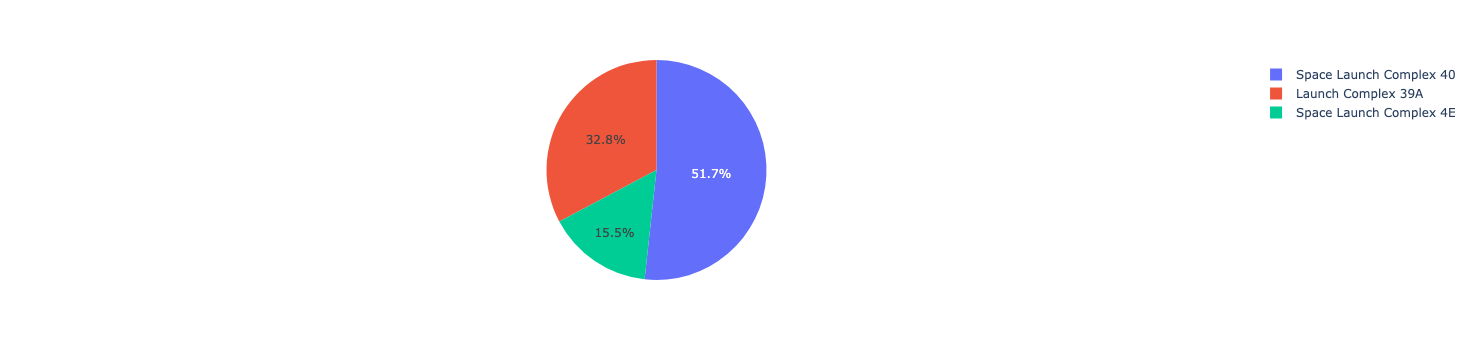

In [59]:
# Pipe chart of SpaceX successful missions by launch site
df2 = df.groupby('launch_site', as_index=False)['class'].sum()
df2_pie = px.pie(
    df2,
    names = 'launch_site', values='class',
)
df2_pie.show()

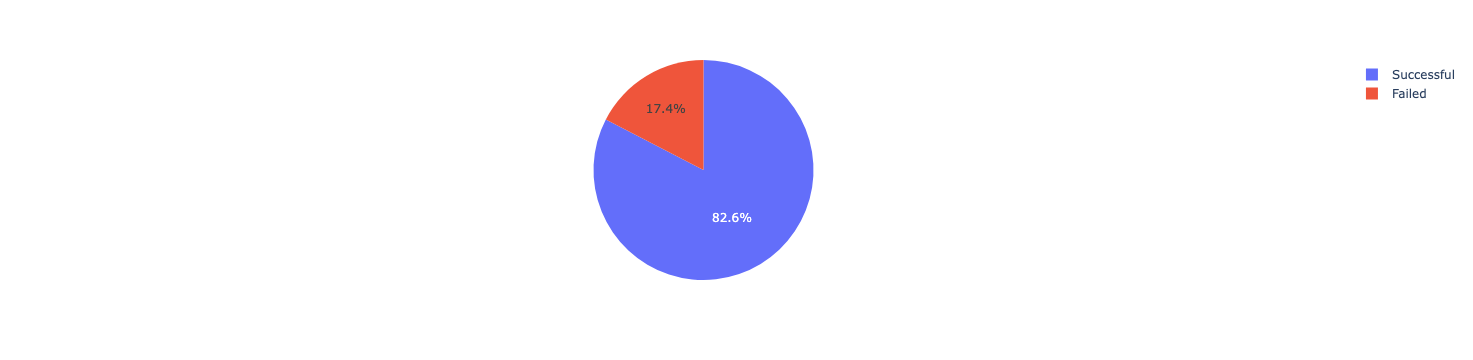

In [60]:
# Sample - Pie chart for LC 39A
df_copy = df.copy()
names = {1:'Successful', 0:'Failed'}
df_copy['labels'] = df_copy['class'].map(names)

launch_site = 'Launch Complex 39A'
mask = df_copy['launch_site']==launch_site
df3 = df_copy[mask].groupby('labels', as_index=False)['class'].count()
df3_pie = px.pie(
    df3,
    names = 'labels',
    values = 'class'
)
df3_pie

In [61]:
type(df3_pie).__name__

'Figure'

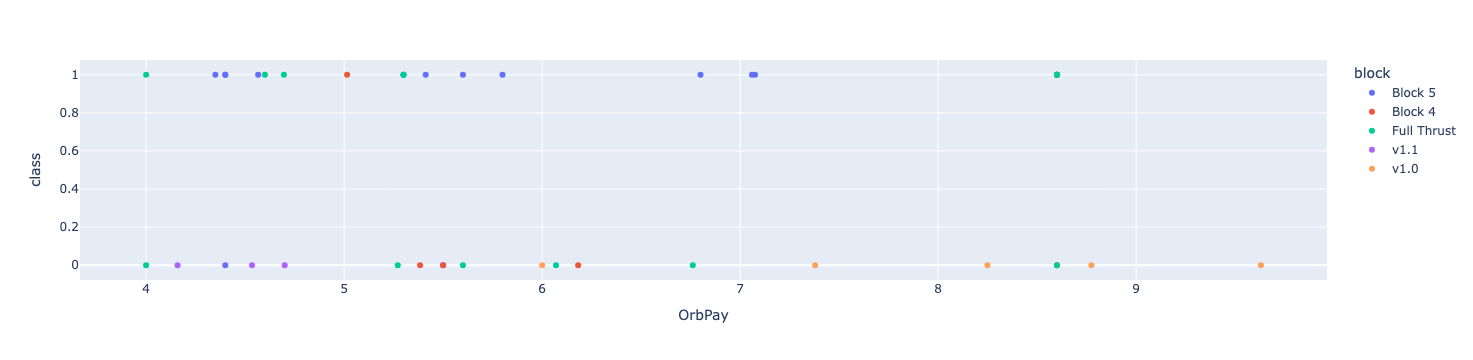

In [62]:
# Correlation between Payload and Success for all sites
xlim = [4,10]
mask_scatter = (df.OrbPay >= xlim[0]) & (df.OrbPay <= xlim[1])
scatter_plot = px.scatter(
    df[mask_scatter],
    x = 'OrbPay',
    y = 'class',
    color = 'block'
)
scatter_plot

In [63]:
lan = list(df2.launch_site)
lan.append('All Sites')
lan

['Launch Complex 39A',
 'Space Launch Complex 40',
 'Space Launch Complex 4E',
 'All Sites']

In [64]:
df.OrbPay.min(), df.OrbPay.max()

(np.float64(0.362), np.float64(16.0))

In [65]:
import math

# Initialize app
external_stylesheets = [dbc.themes.CERULEAN]
app = Dash(__name__)

sites_options = list(df2.launch_site)
sites_options.append('All Sites')

min_payload = df.OrbPay.min()
max_payload = df.OrbPay.max()

app.layout = html.Div(
    children = [
        html.H1(
            'SpaceX Launch Records Dashboard',
            style = {'color': '#503D36',
                     'font-size': 40,
                     'textAlign': 'center'}
        ),
        html.Div([
            dcc.Dropdown(
                options = sites_options,
                value = sites_options[-1],
                id = 'launch_site_input',
            )
        ]),
        html.Div([
            dcc.Graph(figure={}, id='pie-chart')
        ]),
        html.H4(
            'Payload range (tonne)',
            style = {'font-weight': 'bold'}
        ),
        html.Div([
            dcc.RangeSlider(
                math.floor(min_payload), math.ceil(max_payload),
                value = [min_payload, max_payload],
                id = 'payload_input'
            )
        ]),
        html.Div([
            dcc.Graph(figure={}, id='scatter-plot')
        ])
    ]
)

@callback(
    Output('pie-chart', 'figure'),
    Output('scatter-plot', 'figure'),
    Input('launch_site_input', 'value'),
    Input('payload_input', 'value')
)
def get_graphs(launch_site: str, payload_range: list[float]) -> list[Figure]:
    if launch_site == 'All Sites':
        df_pie = df.groupby('launch_site', as_index=False)['class'].sum()
        pie_chart = px.pie(
            df_pie,
            names = 'launch_site', values='class',
            title = 'Total Success Launches By Site'
        )
    else:
        df_copy = df.copy()
        names = {1:'Successful', 0:'Failed'}
        df_copy['labels'] = df_copy['class'].map(names)
        mask_pie = df_copy['launch_site']==launch_site
        
        df_pie = df_copy[mask_pie].groupby('labels', as_index=False)['class'].count()
        pie_chart = px.pie(
            df_pie,
            names = 'labels',
            values = 'class',
            title = 'Total Success Launches for site {}'.format(launch_site)
        )

    mask_scatter = (df.OrbPay >= payload_range[0]) & (df.OrbPay <= payload_range[1])
    scatter_plot = px.scatter(
        df[mask_scatter],
        x = 'OrbPay',
        y = 'class',
        color = 'block',
        title = 'Correlation between Payload and Success for all Sites'
    )

    return [pie_chart, scatter_plot]
    

if __name__ == '__main__':
    app.run(jupyter_mode='external')

Dash app running on http://127.0.0.1:8050/


### Snapshot of result:

![dashboard.png](../reports/figures/dashboard.png)